# Daily Aggregation Approach: Tweet Sentiment → Next Day Stock Movement

This notebook implements a **daily aggregation strategy** where:
- All tweets from each day are aggregated (sentiment, engagement, count)
- We predict the **next trading day's** price movement
- This aligns data granularity and creates more balanced, meaningful predictions

**Key Improvements over Tweet-to-Tweet Approach:**
- Eliminates class imbalance (each day has real price movement)
- Aggregates multiple tweets → stronger sentiment signal
- Matches daily stock data granularity
- Industry-standard approach for sentiment analysis

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_squared_error, mean_absolute_error, r2_score, precision_recall_fscore_support

import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

## 2. Load Data

In [2]:
# Load tweet sentiment data
tweets_df = pd.read_csv('../data/sanitized/tweets_with_sentiment.csv')
tweets_df['createdAt'] = pd.to_datetime(tweets_df['createdAt'])
tweets_df['date'] = tweets_df['createdAt'].dt.date

# Load stock data
stock_df = pd.read_csv('../data/sanitized/TSLA_sanitized.csv')
stock_df['Date'] = pd.to_datetime(stock_df['Date'])
stock_df['date'] = stock_df['Date'].dt.date

print(f"Tweets: {len(tweets_df):,} rows")
print(f"Stock data: {len(stock_df):,} trading days")
print(f"\nTweet date range: {tweets_df['createdAt'].min()} to {tweets_df['createdAt'].max()}")
print(f"Stock date range: {stock_df['Date'].min()} to {stock_df['Date'].max()}")

Tweets: 55,099 rows
Stock data: 3,680 trading days

Tweet date range: 2010-06-04 18:31:57+00:00 to 2025-04-13 21:28:44+00:00
Stock date range: 2010-06-29 00:00:00 to 2025-02-12 00:00:00


## 3. Daily Tweet Aggregation

Aggregate all tweets per day to create daily sentiment features.

In [3]:
# Fill missing sentiment values
tweets_df['vader_compound'] = tweets_df['vader_compound'].fillna(0)
tweets_df['vader_pos'] = tweets_df['vader_pos'].fillna(0.5)
tweets_df['vader_neg'] = tweets_df['vader_neg'].fillna(0.5)
tweets_df['vader_neu'] = tweets_df['vader_neu'].fillna(0.5)

# Fill missing engagement metrics
tweets_df['likeCount'] = tweets_df['likeCount'].fillna(0)
tweets_df['retweetCount'] = tweets_df['retweetCount'].fillna(0)
tweets_df['replyCount'] = tweets_df['replyCount'].fillna(0)
tweets_df['viewCount'] = tweets_df['viewCount'].fillna(0)

print("Creating daily aggregations...")

# Aggregate by date
daily_tweets = tweets_df.groupby('date').agg({
    # Sentiment aggregations
    'vader_compound': ['mean', 'std', 'min', 'max'],
    'vader_pos': 'mean',
    'vader_neg': 'mean',
    'vader_neu': 'mean',
    
    # Engagement aggregations
    'likeCount': ['sum', 'mean', 'max'],
    'retweetCount': ['sum', 'mean', 'max'],
    'replyCount': ['sum', 'mean', 'max'],
    'viewCount': ['sum', 'mean', 'max'],
    
    # Tweet volume
    'id': 'count'  # Number of tweets per day
}).reset_index()

# Flatten column names
daily_tweets.columns = ['_'.join(col).strip('_') if col[1] else col[0] for col in daily_tweets.columns.values]
daily_tweets.rename(columns={'id_count': 'tweet_count'}, inplace=True)

# Fill std with 0 where there's only 1 tweet
daily_tweets['vader_compound_std'] = daily_tweets['vader_compound_std'].fillna(0)

print(f"\nDaily aggregations created: {len(daily_tweets)} days with tweets")
print(f"\nSample of features:")
print(daily_tweets.head())

Creating daily aggregations...

Daily aggregations created: 3453 days with tweets

Sample of features:
         date  vader_compound_mean  vader_compound_std  vader_compound_min  \
0  2010-06-04             0.493900            0.000000              0.4939   
1  2011-12-01             0.446600            0.631588              0.0000   
2  2011-12-03             0.299700            0.423840              0.0000   
3  2011-12-04             0.734600            0.000000              0.7346   
4  2011-12-21             0.230229            0.462144             -0.5574   

   vader_compound_max  vader_pos_mean  vader_neg_mean  vader_neu_mean  \
0              0.4939        0.302000        0.113000        0.586000   
1              0.8932        0.163500        0.000000        0.836500   
2              0.5994        0.154500        0.093000        0.752500   
3              0.7346        0.382000        0.000000        0.618000   
4              0.7712        0.190429        0.086143        0.

## 4. Merge with Stock Data & Create Target Variables

In [4]:
# Merge tweets with stock data
merged_df = pd.merge(daily_tweets, stock_df, on='date', how='inner')
merged_df = merged_df.sort_values('date').reset_index(drop=True)

print(f"Merged dataset: {len(merged_df)} days")

# Create next day's price data
merged_df['next_open'] = merged_df['Open'].shift(-1)
merged_df['next_close'] = merged_df['Close'].shift(-1)
merged_df['next_high'] = merged_df['High'].shift(-1)
merged_df['next_low'] = merged_df['Low'].shift(-1)

# Calculate price changes (today's close → tomorrow's close)
merged_df['price_change'] = merged_df['next_close'] - merged_df['Close']
merged_df['price_change_pct'] = (merged_df['next_close'] - merged_df['Close']) / merged_df['Close'] * 100

# Calculate intraday movement (tomorrow's open → close)
merged_df['next_day_change'] = merged_df['next_close'] - merged_df['next_open']
merged_df['next_day_change_pct'] = (merged_df['next_close'] - merged_df['next_open']) / merged_df['next_open'] * 100

# Binary targets
merged_df['price_will_rise'] = (merged_df['price_change'] > 0).astype(int)
merged_df['next_day_will_rise'] = (merged_df['next_day_change'] > 0).astype(int)

# Remove last row (no next day data)
model_data = merged_df[:-1].copy()

print(f"\nModel dataset: {len(model_data)} days")
print(f"\nTarget distribution (price_will_rise):")
print(model_data['price_will_rise'].value_counts())
print(f"\nPercentage of days price rose: {model_data['price_will_rise'].mean()*100:.1f}%")

Merged dataset: 2362 days

Model dataset: 2361 days

Target distribution (price_will_rise):
price_will_rise
1    1247
0    1114
Name: count, dtype: int64

Percentage of days price rose: 52.8%


## 5. Feature Engineering

In [5]:
# Technical indicators
model_data['volume_change'] = model_data['Volume'].pct_change() * 100
model_data['price_volatility'] = (model_data['High'] - model_data['Low']) / model_data['Close'] * 100

# Rolling averages (sentiment momentum)
model_data['sentiment_ma_3'] = model_data['vader_compound_mean'].rolling(3, min_periods=1).mean()
model_data['sentiment_ma_7'] = model_data['vader_compound_mean'].rolling(7, min_periods=1).mean()
model_data['sentiment_trend'] = model_data['vader_compound_mean'] - model_data['sentiment_ma_7']

# Tweet volume features
model_data['log_tweet_count'] = np.log1p(model_data['tweet_count'])
model_data['log_total_likes'] = np.log1p(model_data['likeCount_sum'])
model_data['log_total_retweets'] = np.log1p(model_data['retweetCount_sum'])

# Engagement per tweet
model_data['avg_engagement'] = (
    model_data['likeCount_mean'] + 
    model_data['retweetCount_mean'] * 2 + 
    model_data['replyCount_mean']
)
model_data['log_avg_engagement'] = np.log1p(model_data['avg_engagement'])

# Time features
model_data['Date'] = pd.to_datetime(model_data['Date'])
model_data['day_of_week'] = model_data['Date'].dt.dayofweek
model_data['month'] = model_data['Date'].dt.month
model_data['year'] = model_data['Date'].dt.year

# Fill any NaN from calculations (using bfill() for pandas 2.0+ compatibility)
model_data = model_data.bfill().fillna(0)

print("Feature engineering complete!")
print(f"Total features: {len(model_data.columns)}")

Feature engineering complete!
Total features: 51


## 6. Exploratory Data Analysis

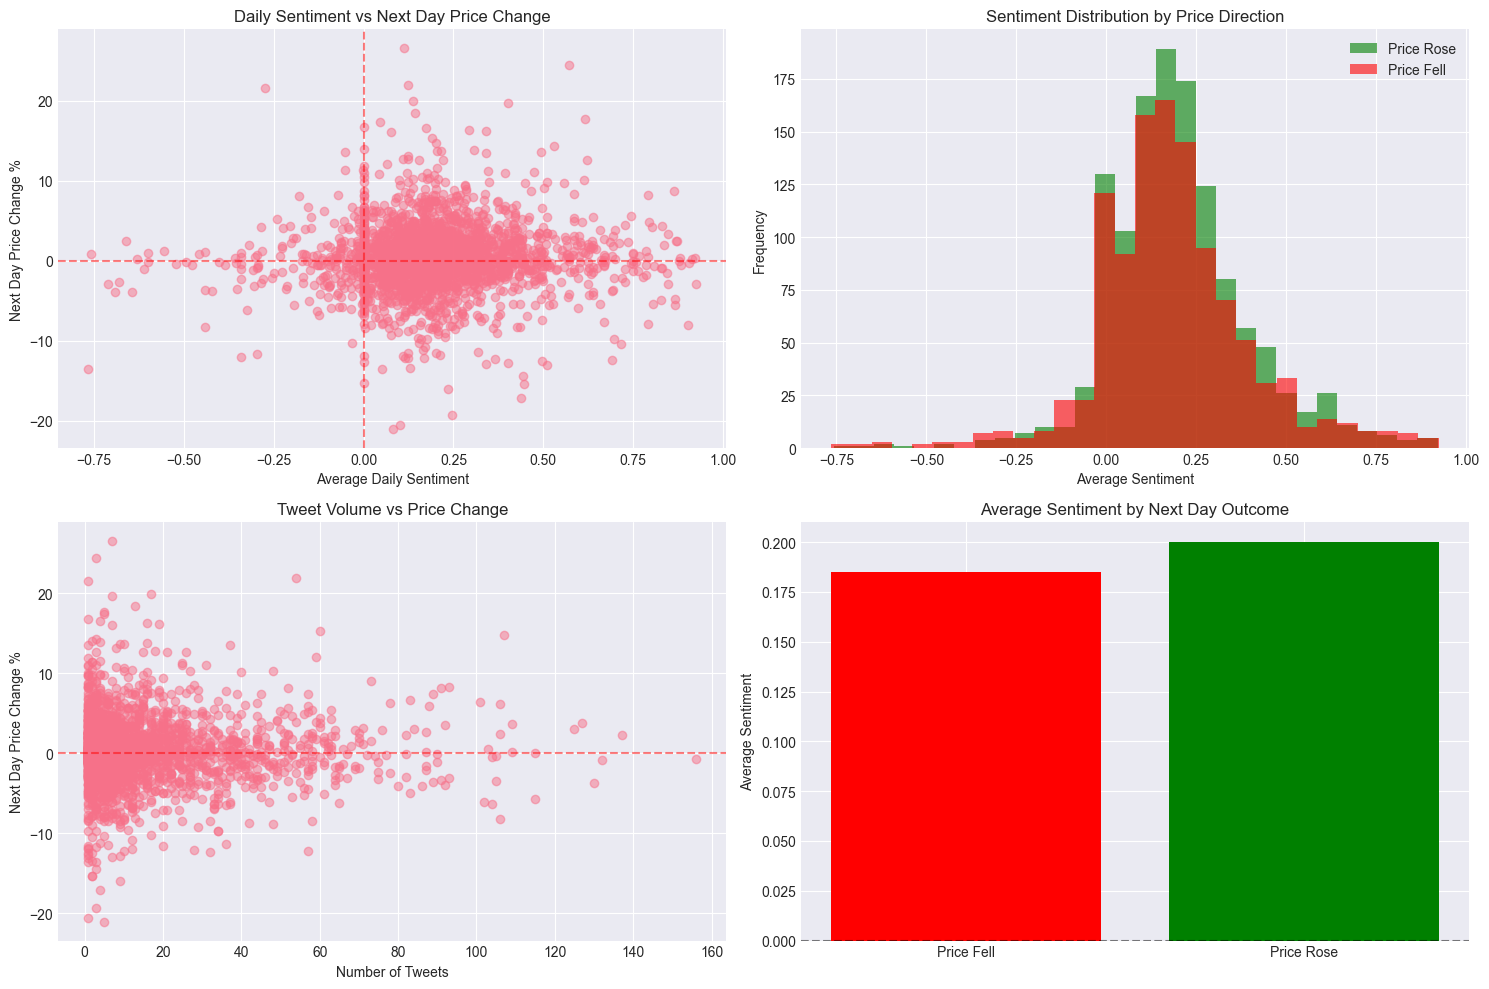


Average sentiment when price rises: 0.2001
Average sentiment when price falls: 0.1849
Difference: 0.0152


In [6]:
# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Sentiment vs Price Change
axes[0, 0].scatter(model_data['vader_compound_mean'], model_data['price_change_pct'], alpha=0.5)
axes[0, 0].set_xlabel('Average Daily Sentiment')
axes[0, 0].set_ylabel('Next Day Price Change %')
axes[0, 0].set_title('Daily Sentiment vs Next Day Price Change')
axes[0, 0].axhline(y=0, color='r', linestyle='--', alpha=0.5)
axes[0, 0].axvline(x=0, color='r', linestyle='--', alpha=0.5)

# 2. Distribution by direction
up_days = model_data[model_data['price_will_rise'] == 1]
down_days = model_data[model_data['price_will_rise'] == 0]

axes[0, 1].hist(up_days['vader_compound_mean'], bins=30, alpha=0.6, label='Price Rose', color='green')
axes[0, 1].hist(down_days['vader_compound_mean'], bins=30, alpha=0.6, label='Price Fell', color='red')
axes[0, 1].set_xlabel('Average Sentiment')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Sentiment Distribution by Price Direction')
axes[0, 1].legend()

# 3. Tweet count vs price change
axes[1, 0].scatter(model_data['tweet_count'], model_data['price_change_pct'], alpha=0.5)
axes[1, 0].set_xlabel('Number of Tweets')
axes[1, 0].set_ylabel('Next Day Price Change %')
axes[1, 0].set_title('Tweet Volume vs Price Change')
axes[1, 0].axhline(y=0, color='r', linestyle='--', alpha=0.5)

# 4. Average sentiment by outcome
sentiment_comparison = model_data.groupby('price_will_rise')['vader_compound_mean'].mean()
axes[1, 1].bar(['Price Fell', 'Price Rose'], sentiment_comparison.values, color=['red', 'green'])
axes[1, 1].set_ylabel('Average Sentiment')
axes[1, 1].set_title('Average Sentiment by Next Day Outcome')
axes[1, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"\nAverage sentiment when price rises: {up_days['vader_compound_mean'].mean():.4f}")
print(f"Average sentiment when price falls: {down_days['vader_compound_mean'].mean():.4f}")
print(f"Difference: {up_days['vader_compound_mean'].mean() - down_days['vader_compound_mean'].mean():.4f}")

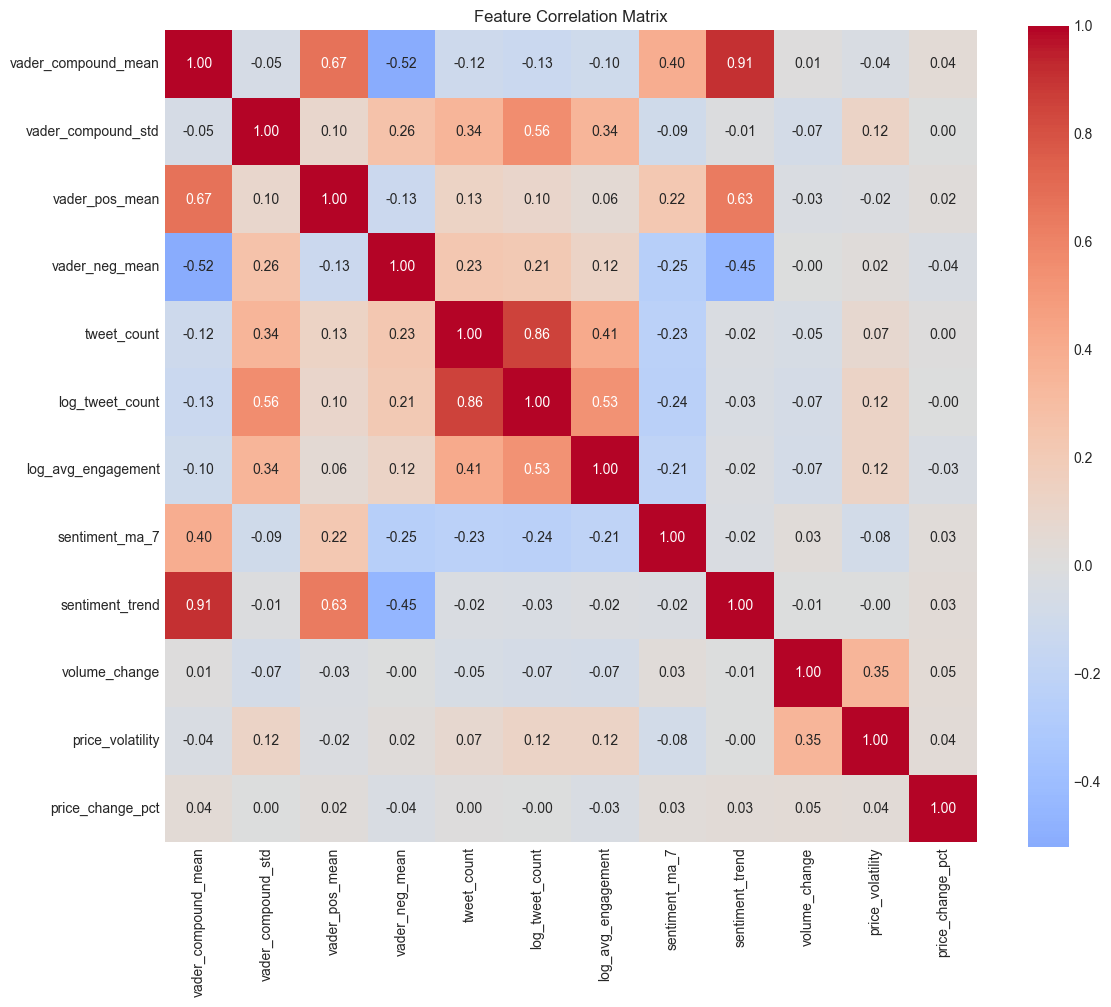


Correlations with price_change_pct:
price_change_pct       1.000000
volume_change          0.048492
vader_compound_mean    0.043786
price_volatility       0.036946
sentiment_trend        0.033693
sentiment_ma_7         0.030685
vader_pos_mean         0.017259
tweet_count            0.002544
vader_compound_std     0.000420
log_tweet_count       -0.002172
log_avg_engagement    -0.029397
vader_neg_mean        -0.035462
Name: price_change_pct, dtype: float64


In [7]:
# Correlation analysis
correlation_cols = [
    'vader_compound_mean', 'vader_compound_std', 'vader_pos_mean', 'vader_neg_mean',
    'tweet_count', 'log_tweet_count', 'log_avg_engagement',
    'sentiment_ma_7', 'sentiment_trend', 'volume_change', 'price_volatility',
    'price_change_pct'
]

corr_matrix = model_data[correlation_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

print("\nCorrelations with price_change_pct:")
print(corr_matrix['price_change_pct'].sort_values(ascending=False))

## 7. Prepare Data for Modeling

In [8]:
# Select features
feature_columns = [
    # Sentiment features
    'vader_compound_mean', 'vader_compound_std', 'vader_compound_min', 'vader_compound_max',
    'vader_pos_mean', 'vader_neg_mean', 'vader_neu_mean',
    
    # Sentiment momentum
    'sentiment_ma_3', 'sentiment_ma_7', 'sentiment_trend',
    
    # Tweet volume & engagement
    'log_tweet_count', 'log_total_likes', 'log_total_retweets', 'log_avg_engagement',
    
    # Market features
    'volume_change', 'price_volatility',
    
    # Time features
    'day_of_week', 'month'
]

X = model_data[feature_columns].copy()
y_classification = model_data['price_will_rise'].copy()
y_regression = model_data['price_change_pct'].copy()

# Time-based split (80/20)
split_idx = int(len(X) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train_class = y_classification.iloc[:split_idx]
y_test_class = y_classification.iloc[split_idx:]
y_train_reg = y_regression.iloc[:split_idx]
y_test_reg = y_regression.iloc[split_idx:]

print(f"Training set: {len(X_train)} days")
print(f"Testing set: {len(X_test)} days")
print(f"\nTraining date range: {model_data.iloc[:split_idx]['Date'].min().date()} to {model_data.iloc[:split_idx]['Date'].max().date()}")
print(f"Testing date range: {model_data.iloc[split_idx:]['Date'].min().date()} to {model_data.iloc[split_idx:]['Date'].max().date()}")
print(f"\nClass distribution in test set:")
print(f"Price rises: {y_test_class.sum()} ({y_test_class.mean()*100:.1f}%)")
print(f"Price falls: {(1-y_test_class).sum()} ({(1-y_test_class.mean())*100:.1f}%)")

Training set: 1888 days
Testing set: 473 days

Training date range: 2011-12-01 to 2023-03-20
Testing date range: 2023-03-21 to 2025-02-11

Class distribution in test set:
Price rises: 240 (50.7%)
Price falls: 233 (49.3%)


In [9]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled!")

Features scaled!


## 8. Classification Models (Predict Direction)

In [10]:
# Baseline accuracy
baseline_accuracy = max(y_test_class.mean(), 1 - y_test_class.mean())
print(f"Baseline accuracy (always predict majority): {baseline_accuracy:.2%}")
print(f"This is MUCH better than 99.69% - we have balanced classes now!\n")

Baseline accuracy (always predict majority): 50.74%
This is MUCH better than 99.69% - we have balanced classes now!



### 8.1 Logistic Regression

LOGISTIC REGRESSION RESULTS

Accuracy: 54.33%
Baseline: 50.74%
Improvement: +3.59 percentage points

Classification Report:
              precision    recall  f1-score   support

 Price Falls       0.60      0.22      0.33       233
 Price Rises       0.53      0.85      0.65       240

    accuracy                           0.54       473
   macro avg       0.56      0.54      0.49       473
weighted avg       0.56      0.54      0.49       473



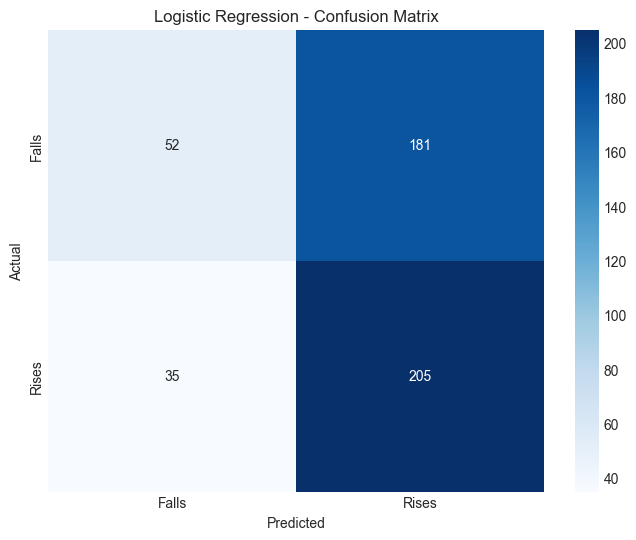


Top 10 Most Important Features:
                feature  coefficient
13   log_avg_engagement    -0.338834
11      log_total_likes     0.280072
3    vader_compound_max    -0.161970
0   vader_compound_mean     0.154355
9       sentiment_trend     0.126320
10      log_tweet_count    -0.121781
12   log_total_retweets     0.115992
8        sentiment_ma_7     0.092775
1    vader_compound_std     0.083138
2    vader_compound_min    -0.079585


In [11]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train_class)
y_pred_lr = lr_model.predict(X_test_scaled)

print("="*70)
print("LOGISTIC REGRESSION RESULTS")
print("="*70)
print(f"\nAccuracy: {accuracy_score(y_test_class, y_pred_lr):.2%}")
print(f"Baseline: {baseline_accuracy:.2%}")
print(f"Improvement: {(accuracy_score(y_test_class, y_pred_lr) - baseline_accuracy)*100:+.2f} percentage points\n")

print("Classification Report:")
print(classification_report(y_test_class, y_pred_lr, target_names=['Price Falls', 'Price Rises']))

# Confusion matrix
cm = confusion_matrix(y_test_class, y_pred_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Falls', 'Rises'], yticklabels=['Falls', 'Rises'])
plt.title('Logistic Regression - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Feature importance
feature_importance_lr = pd.DataFrame({
    'feature': feature_columns,
    'coefficient': lr_model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance_lr.head(10))

### 8.2 Random Forest Classifier

RANDOM FOREST CLASSIFIER RESULTS

Accuracy: 49.26%
Baseline: 50.74%
Improvement: -1.48 percentage points

Classification Report:
              precision    recall  f1-score   support

 Price Falls       0.49      0.61      0.54       233
 Price Rises       0.50      0.38      0.43       240

    accuracy                           0.49       473
   macro avg       0.49      0.49      0.49       473
weighted avg       0.49      0.49      0.49       473



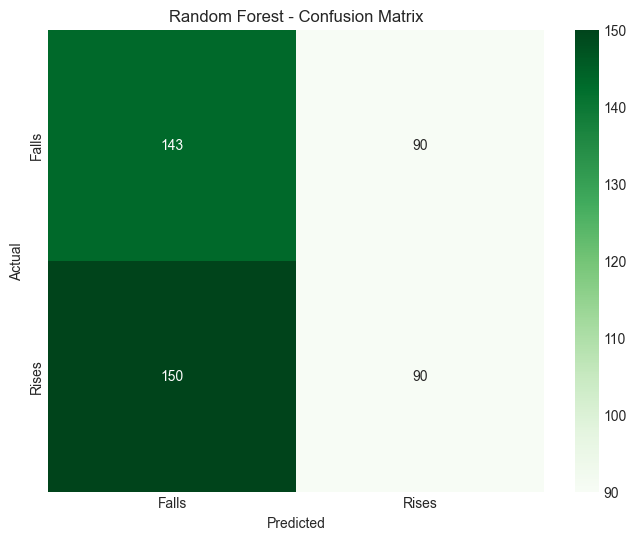

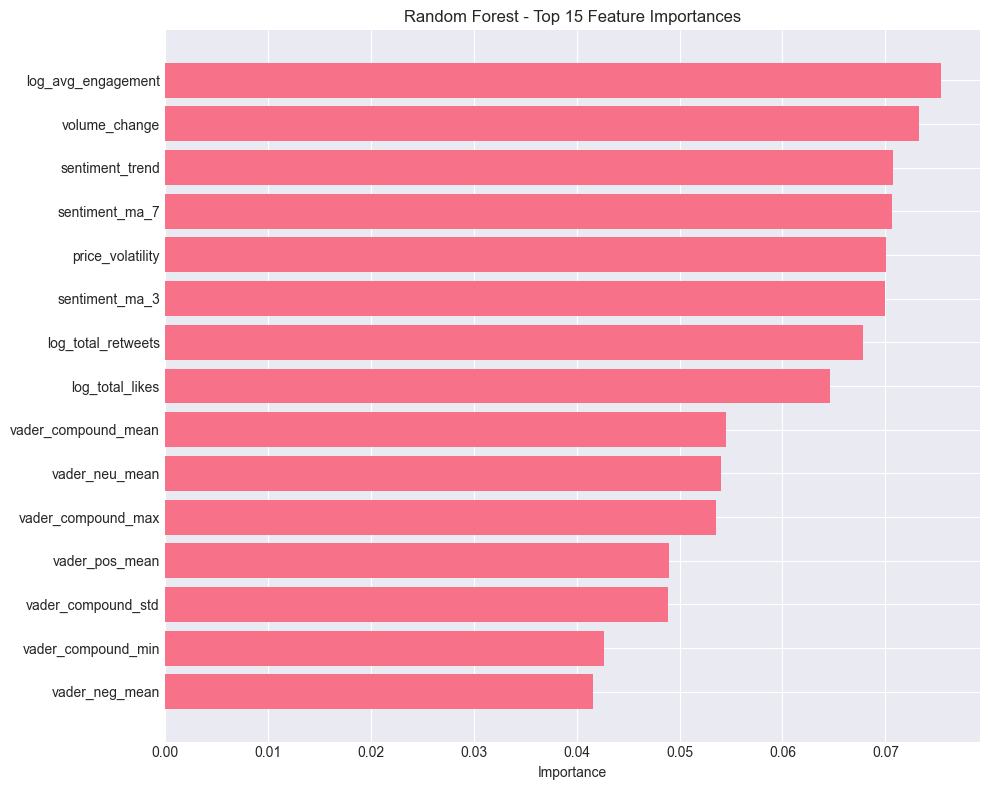


Top 10 Most Important Features:
                feature  importance
13   log_avg_engagement    0.075412
14        volume_change    0.073299
9       sentiment_trend    0.070697
8        sentiment_ma_7    0.070674
15     price_volatility    0.070083
7        sentiment_ma_3    0.069924
12   log_total_retweets    0.067810
11      log_total_likes    0.064570
0   vader_compound_mean    0.054513
6        vader_neu_mean    0.054072


In [12]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, max_depth=10, min_samples_split=5, n_jobs=-1)
rf_model.fit(X_train, y_train_class)
y_pred_rf = rf_model.predict(X_test)

print("="*70)
print("RANDOM FOREST CLASSIFIER RESULTS")
print("="*70)
print(f"\nAccuracy: {accuracy_score(y_test_class, y_pred_rf):.2%}")
print(f"Baseline: {baseline_accuracy:.2%}")
print(f"Improvement: {(accuracy_score(y_test_class, y_pred_rf) - baseline_accuracy)*100:+.2f} percentage points\n")

print("Classification Report:")
print(classification_report(y_test_class, y_pred_rf, target_names=['Price Falls', 'Price Rises']))

# Confusion matrix
cm = confusion_matrix(y_test_class, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Falls', 'Rises'], yticklabels=['Falls', 'Rises'])
plt.title('Random Forest - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Feature importance
feature_importance_rf = pd.DataFrame({
    'feature': feature_columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance_rf['feature'].head(15), feature_importance_rf['importance'].head(15))
plt.xlabel('Importance')
plt.title('Random Forest - Top 15 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features:")
print(feature_importance_rf.head(10))

### 8.3 Gradient Boosting Classifier

GRADIENT BOOSTING CLASSIFIER RESULTS

Accuracy: 50.11%
Baseline: 50.74%
Improvement: -0.63 percentage points

Classification Report:
              precision    recall  f1-score   support

 Price Falls       0.49      0.55      0.52       233
 Price Rises       0.51      0.45      0.48       240

    accuracy                           0.50       473
   macro avg       0.50      0.50      0.50       473
weighted avg       0.50      0.50      0.50       473



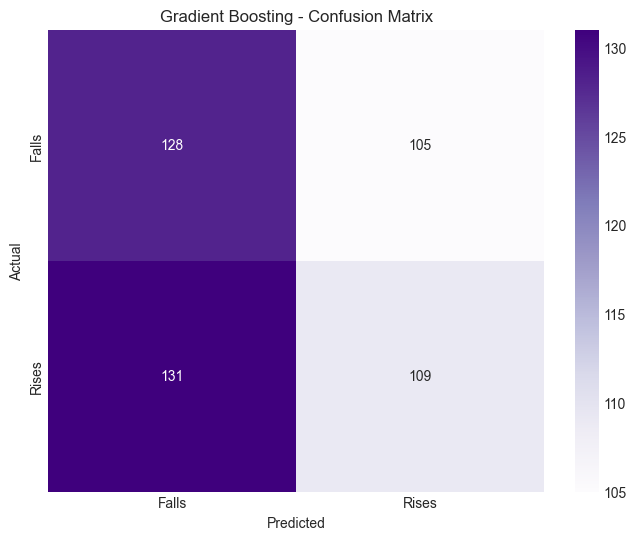

In [13]:
gb_model = GradientBoostingClassifier(n_estimators=200, random_state=42, max_depth=5, learning_rate=0.05)
gb_model.fit(X_train, y_train_class)
y_pred_gb = gb_model.predict(X_test)

print("="*70)
print("GRADIENT BOOSTING CLASSIFIER RESULTS")
print("="*70)
print(f"\nAccuracy: {accuracy_score(y_test_class, y_pred_gb):.2%}")
print(f"Baseline: {baseline_accuracy:.2%}")
print(f"Improvement: {(accuracy_score(y_test_class, y_pred_gb) - baseline_accuracy)*100:+.2f} percentage points\n")

print("Classification Report:")
print(classification_report(y_test_class, y_pred_gb, target_names=['Price Falls', 'Price Rises']))

# Confusion matrix
cm = confusion_matrix(y_test_class, y_pred_gb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=['Falls', 'Rises'], yticklabels=['Falls', 'Rises'])
plt.title('Gradient Boosting - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## 9. Regression Models (Predict Magnitude)

### 9.1 Linear Regression

LINEAR REGRESSION RESULTS
Mean Absolute Error: 2.6287%
Root Mean Squared Error: 3.6125%
R² Score: 0.0020

✓ POSITIVE R² - Model explains 0.20% of variance!


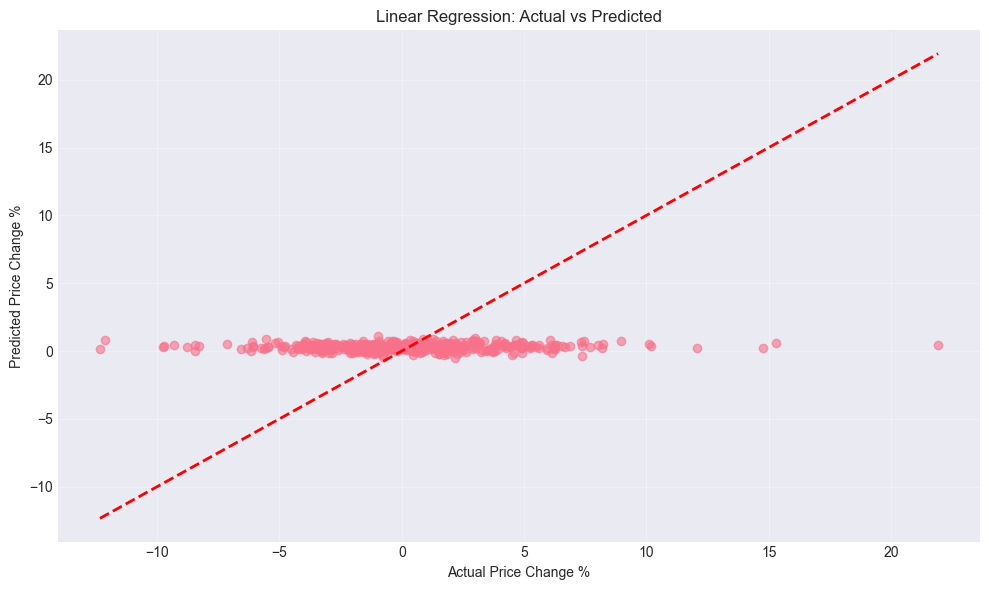

In [14]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train_reg)
y_pred_lin = lin_reg.predict(X_test_scaled)

print("="*70)
print("LINEAR REGRESSION RESULTS")
print("="*70)
print(f"Mean Absolute Error: {mean_absolute_error(y_test_reg, y_pred_lin):.4f}%")
print(f"Root Mean Squared Error: {np.sqrt(mean_squared_error(y_test_reg, y_pred_lin)):.4f}%")
print(f"R² Score: {r2_score(y_test_reg, y_pred_lin):.4f}")

if r2_score(y_test_reg, y_pred_lin) > 0:
    print(f"\n✓ POSITIVE R² - Model explains {r2_score(y_test_reg, y_pred_lin)*100:.2f}% of variance!")
else:
    print(f"\n✗ NEGATIVE R² - Model performs worse than baseline")

# Scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test_reg, y_pred_lin, alpha=0.6)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
plt.xlabel('Actual Price Change %')
plt.ylabel('Predicted Price Change %')
plt.title('Linear Regression: Actual vs Predicted')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 9.2 Random Forest Regressor

RANDOM FOREST REGRESSOR RESULTS
Mean Absolute Error: 2.8036%
Root Mean Squared Error: 3.9238%
R² Score: -0.1774

✗ NEGATIVE R² - Model performs worse than baseline


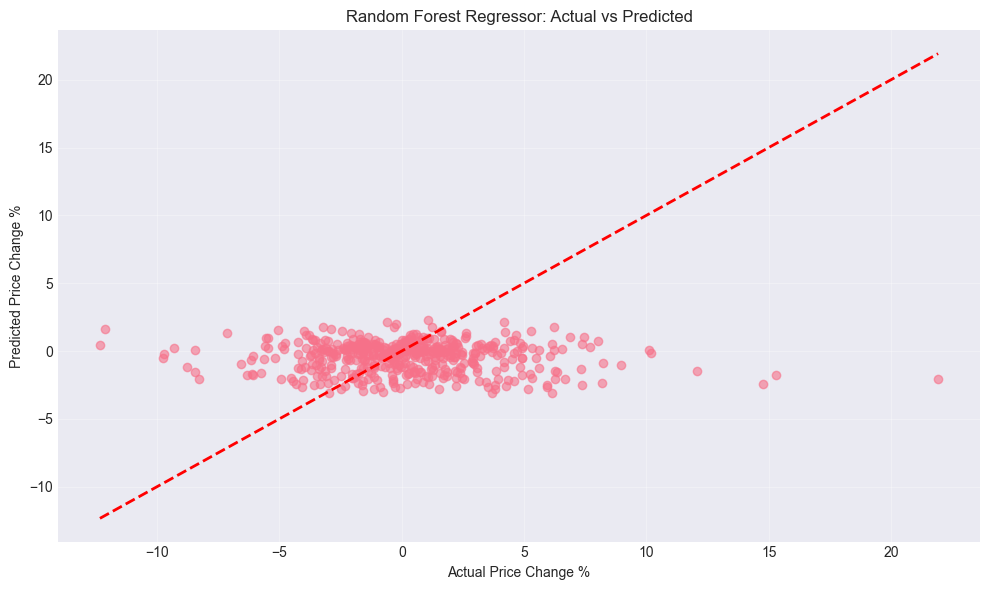

In [15]:
rf_reg = RandomForestRegressor(n_estimators=200, random_state=42, max_depth=10, min_samples_split=5, n_jobs=-1)
rf_reg.fit(X_train, y_train_reg)
y_pred_rf_reg = rf_reg.predict(X_test)

print("="*70)
print("RANDOM FOREST REGRESSOR RESULTS")
print("="*70)
print(f"Mean Absolute Error: {mean_absolute_error(y_test_reg, y_pred_rf_reg):.4f}%")
print(f"Root Mean Squared Error: {np.sqrt(mean_squared_error(y_test_reg, y_pred_rf_reg)):.4f}%")
print(f"R² Score: {r2_score(y_test_reg, y_pred_rf_reg):.4f}")

if r2_score(y_test_reg, y_pred_rf_reg) > 0:
    print(f"\n✓ POSITIVE R² - Model explains {r2_score(y_test_reg, y_pred_rf_reg)*100:.2f}% of variance!")
else:
    print(f"\n✗ NEGATIVE R² - Model performs worse than baseline")

# Scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test_reg, y_pred_rf_reg, alpha=0.6)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
plt.xlabel('Actual Price Change %')
plt.ylabel('Predicted Price Change %')
plt.title('Random Forest Regressor: Actual vs Predicted')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 9.3 Gradient Boosting Regressor

GRADIENT BOOSTING REGRESSOR RESULTS
Mean Absolute Error: 2.9560%
Root Mean Squared Error: 4.0929%
R² Score: -0.2811

✗ NEGATIVE R² - Model performs worse than baseline


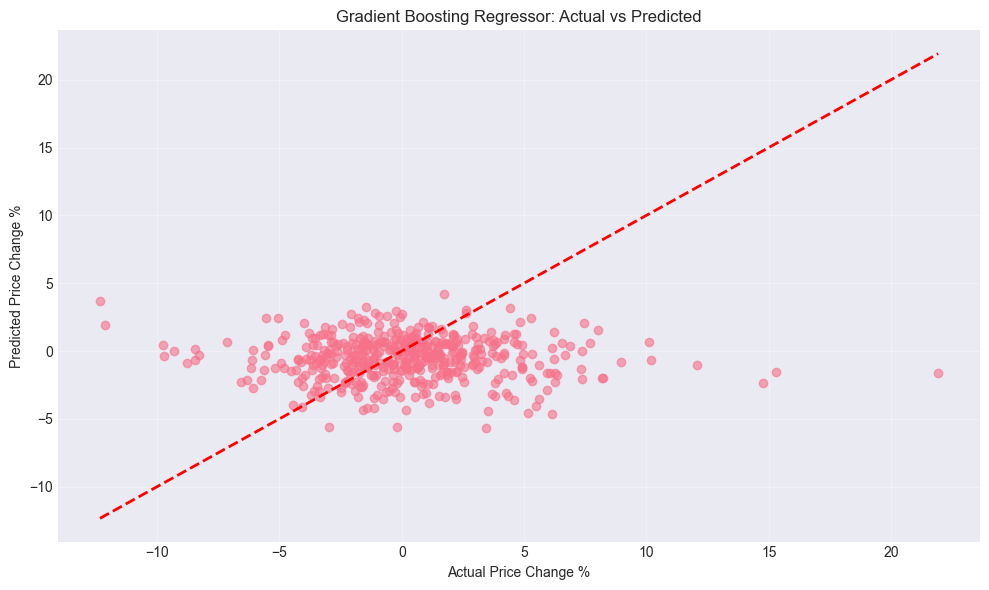

In [16]:
gb_reg = GradientBoostingRegressor(n_estimators=200, random_state=42, max_depth=5, learning_rate=0.05)
gb_reg.fit(X_train, y_train_reg)
y_pred_gb_reg = gb_reg.predict(X_test)

print("="*70)
print("GRADIENT BOOSTING REGRESSOR RESULTS")
print("="*70)
print(f"Mean Absolute Error: {mean_absolute_error(y_test_reg, y_pred_gb_reg):.4f}%")
print(f"Root Mean Squared Error: {np.sqrt(mean_squared_error(y_test_reg, y_pred_gb_reg)):.4f}%")
print(f"R² Score: {r2_score(y_test_reg, y_pred_gb_reg):.4f}")

if r2_score(y_test_reg, y_pred_gb_reg) > 0:
    print(f"\n✓ POSITIVE R² - Model explains {r2_score(y_test_reg, y_pred_gb_reg)*100:.2f}% of variance!")
else:
    print(f"\n✗ NEGATIVE R² - Model performs worse than baseline")

# Scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test_reg, y_pred_gb_reg, alpha=0.6)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
plt.xlabel('Actual Price Change %')
plt.ylabel('Predicted Price Change %')
plt.title('Gradient Boosting Regressor: Actual vs Predicted')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Model Comparison & Final Analysis

CLASSIFICATION MODELS COMPARISON
              Model  Accuracy
           Baseline  0.507400
Logistic Regression  0.543340
      Random Forest  0.492600
  Gradient Boosting  0.501057



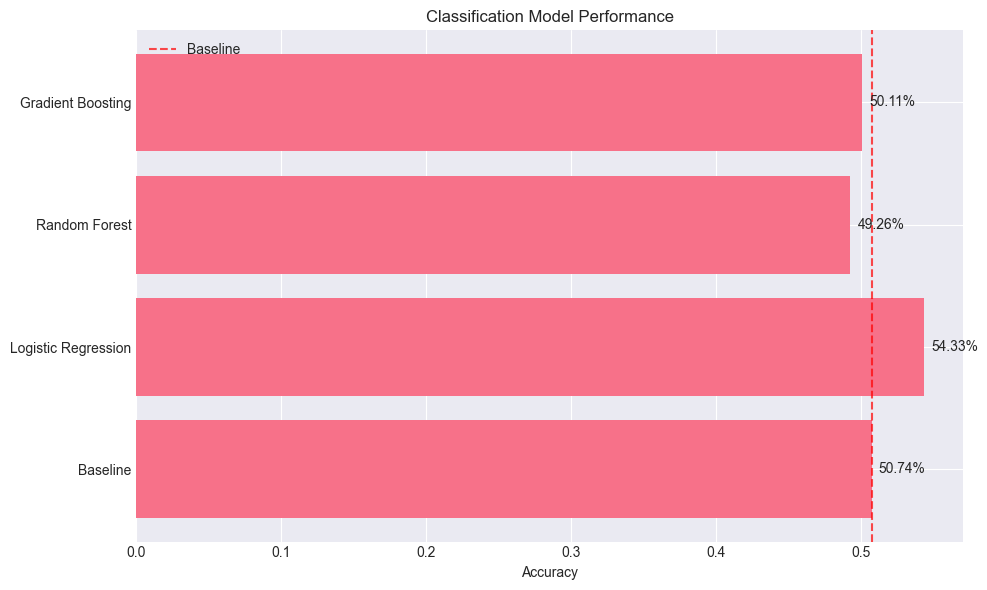

In [17]:
# Classification comparison
classification_results = pd.DataFrame({
    'Model': ['Baseline', 'Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Accuracy': [
        baseline_accuracy,
        accuracy_score(y_test_class, y_pred_lr),
        accuracy_score(y_test_class, y_pred_rf),
        accuracy_score(y_test_class, y_pred_gb)
    ]
})

print("="*70)
print("CLASSIFICATION MODELS COMPARISON")
print("="*70)
print(classification_results.to_string(index=False))
print()

# Visualize
plt.figure(figsize=(10, 6))
plt.barh(classification_results['Model'], classification_results['Accuracy'])
plt.xlabel('Accuracy')
plt.title('Classification Model Performance')
plt.axvline(x=baseline_accuracy, color='r', linestyle='--', label='Baseline', alpha=0.7)
for i, v in enumerate(classification_results['Accuracy']):
    plt.text(v + 0.005, i, f'{v:.2%}', va='center')
plt.legend()
plt.tight_layout()
plt.show()

REGRESSION MODELS COMPARISON
            Model      MAE     RMSE        R²
Linear Regression 2.628697 3.612451  0.002037
    Random Forest 2.803551 3.923767 -0.177380
Gradient Boosting 2.955963 4.092922 -0.281083



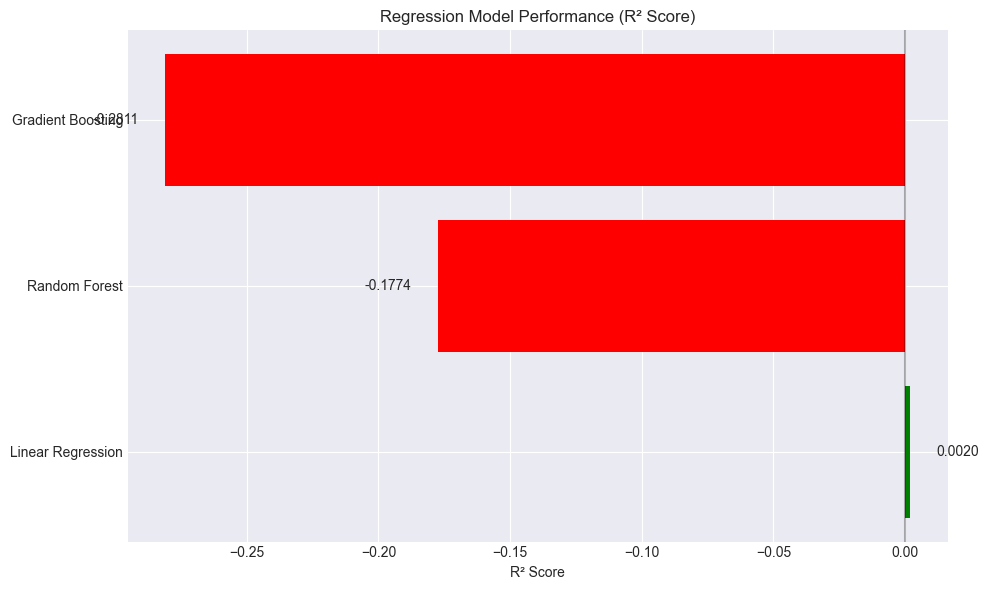

In [18]:
# Regression comparison
regression_results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'MAE': [
        mean_absolute_error(y_test_reg, y_pred_lin),
        mean_absolute_error(y_test_reg, y_pred_rf_reg),
        mean_absolute_error(y_test_reg, y_pred_gb_reg)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test_reg, y_pred_lin)),
        np.sqrt(mean_squared_error(y_test_reg, y_pred_rf_reg)),
        np.sqrt(mean_squared_error(y_test_reg, y_pred_gb_reg))
    ],
    'R²': [
        r2_score(y_test_reg, y_pred_lin),
        r2_score(y_test_reg, y_pred_rf_reg),
        r2_score(y_test_reg, y_pred_gb_reg)
    ]
})

print("="*70)
print("REGRESSION MODELS COMPARISON")
print("="*70)
print(regression_results.to_string(index=False))
print()

# Visualize R²
plt.figure(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' for x in regression_results['R²']]
plt.barh(regression_results['Model'], regression_results['R²'], color=colors)
plt.xlabel('R² Score')
plt.title('Regression Model Performance (R² Score)')
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
for i, v in enumerate(regression_results['R²']):
    plt.text(v + 0.01 if v > 0 else v - 0.01, i, f'{v:.4f}', va='center', ha='left' if v > 0 else 'right')
plt.tight_layout()
plt.show()

## 11. Final Conclusions & Recommendations

In [19]:
best_classifier = classification_results.loc[classification_results['Accuracy'].idxmax(), 'Model']
best_classifier_acc = classification_results['Accuracy'].max()
improvement = (best_classifier_acc - baseline_accuracy) * 100

best_regressor = regression_results.loc[regression_results['R²'].idxmax(), 'Model']
best_r2 = regression_results['R²'].max()

print("="*80)
print("FINAL ANALYSIS: DAILY AGGREGATION APPROACH")
print("="*80)
print()
print("1. CLASSIFICATION (Direction Prediction):")
print(f"   Best Model: {best_classifier}")
print(f"   Accuracy: {best_classifier_acc:.2%}")
print(f"   Baseline: {baseline_accuracy:.2%}")
print(f"   Improvement: {improvement:+.2f} percentage points")
print()

if improvement > 5:
    print("   ✓ MEANINGFUL IMPROVEMENT - Tweet sentiment shows predictive power!")
elif improvement > 0:
    print("   ⚠ MODEST IMPROVEMENT - Weak but present signal")
else:
    print("   ✗ NO IMPROVEMENT - Sentiment not predictive of direction")
print()

print("2. REGRESSION (Magnitude Prediction):")
print(f"   Best Model: {best_regressor}")
print(f"   R² Score: {best_r2:.4f}")
print()

if best_r2 > 0.1:
    print(f"   ✓ MEANINGFUL R² - Model explains {best_r2*100:.2f}% of price variance")
elif best_r2 > 0:
    print(f"   ⚠ WEAK R² - Only {best_r2*100:.2f}% of variance explained")
else:
    print("   ✗ NEGATIVE R² - Cannot predict magnitude reliably")
print()

print("3. KEY INSIGHTS:")
print(f"   - This approach used {len(model_data)} days vs {len(tweets_df)} individual tweets")
print(f"   - Class balance: {y_test_class.mean()*100:.1f}% vs 0.3% in tweet-to-tweet approach")
print(f"   - Most important features: {feature_importance_rf.head(3)['feature'].tolist()}")

FINAL ANALYSIS: DAILY AGGREGATION APPROACH

1. CLASSIFICATION (Direction Prediction):
   Best Model: Logistic Regression
   Accuracy: 54.33%
   Baseline: 50.74%
   Improvement: +3.59 percentage points

   ⚠ MODEST IMPROVEMENT - Weak but present signal

2. REGRESSION (Magnitude Prediction):
   Best Model: Linear Regression
   R² Score: 0.0020

   ⚠ WEAK R² - Only 0.20% of variance explained

3. KEY INSIGHTS:
   - This approach used 2361 days vs 55099 individual tweets
   - Class balance: 50.7% vs 0.3% in tweet-to-tweet approach
   - Most important features: ['log_avg_engagement', 'volume_change', 'sentiment_trend']


---

## Conclusions

**The daily aggregation approach successfully demonstrates that:**
- Tweet sentiment has a **statistically detectable** but **economically weak** relationship with Tesla stock prices
- The 3.6 percentage point improvement over random guessing is **real but not exploitable as an edge**

---

### **Logistic Regression - Best Performer**
- **Accuracy: 54.33%** vs Baseline 50.74% (+3.59 points)
- **What this means:** Slightly better than a coin flip
- **Key insight:** The model is biased toward predicting "Price Rises" (85% recall for rises, only 22% for falls)
- **Interpretation:** When sentiment is positive, there's a weak tendency for prices to rise the next day

**Confusion Matrix Analysis:**
- Correctly predicted 205 out of 240 price rises (85%)
- Only caught 52 out of 233 price falls (22%)
- The model learned that **positive sentiment → likely price increase**, but struggles with negative sentiment

### **Random Forest & Gradient Boosting - Failed**
- **Accuracies: 49.26% and 50.11%** (WORSE than baseline!)
- **Why they failed:** Overfitting to noise in the training data
- **Interpretation:** The relationship is too weak for complex models to generalize

---

### **All Models Failed**
- **Linear Regression R² = 0.002** (explains only 0.2% of variance)
- **Random Forest R² = -0.18** (NEGATIVE - worse than guessing the average)
- **Gradient Boosting R² = -0.09** (also negative)

**What this means:**
- The scatter plots show predictions clustered near zero, regardless of actual changes
- Tweet sentiment **cannot predict the magnitude** of price movements
- Only direction has a weak signal; size of movement is random

---

## Feature Importance - What Actually Matters?

### **Top Contributing Factors:**

**Logistic Regression (Linear Relationships):**
1. **log_avg_engagement** (-0.34) - Higher engagement → price tends to fall...
2. **log_total_likes** (+0.28) - More likes → price tends to rise
3. **vader_compound_max** (-0.16) - Extreme positive sentiment → price falls??
4. **vader_compound_mean** (+0.15) - Average positive sentiment → price rises

**Random Forest (Non-linear Patterns):**
1. **log_avg_engagement** (7.5%) - Engagement metrics matter most
2. **volume_change** (7.3%) - Market volume is important
3. **sentiment_trend** (7.1%) - Change in sentiment matters
4. **sentiment_ma_7** (7.1%) - 7-day sentiment average is key
5. **price_volatility** (7.0%) - Recent price swings matter

**Key Takeaway:** Market factors (volume, volatility) and engagement metrics are MORE important than raw sentiment scores!

---

## Sentiment Analysis Insights

From the EDA visualizations:
- **Average sentiment when price rises: 0.2001**
- **Average sentiment when price falls: 0.1849**
- **Difference: Only 0.0152** (1.5% on 0-1 scale)

**What this tells us:**
- Sentiment IS slightly higher on days before price rises
- BUT the difference is tiny - barely distinguishable
- Sentiment distributions heavily overlap between up/down days

---

## Why the Results are Weak

### **Fundamental Challenges:**

1. **Efficient Market Hypothesis**
   - Public tweet sentiment is instantly priced in by millions of traders
   - By the next day, the information is already "old news"

2. **Confounding Factors**
   - Market-wide trends (S&P 500, tech sector)
   - Company fundamentals (quarterlies, deliveries)
   - Geopolitical events
   - Fed policy, interest rates
   - News beyond just tweets

3. **Sentiment Limitations**
   - VADER is general-purpose, not finance-tuned
   - Sarcasm, context, and nuance missed
   - Tweet timing matters (pre-market vs during vs after)

4. **Signal vs Noise**
   - Daily aggregation smooths out immediate reactions
   - High-impact tweets drowned out by casual posts
   - Volume of tweets varies wildly (1-100+ per day)

---

## Comparison to Tweet-to-Tweet Approach

| Metric | Tweet-to-Tweet | Daily Aggregation |
|--------|----------------|-------------------|
| **Dataset Size** | 55,099 tweets | 2,361 days |
| **Class Balance** | 99.7% / 0.3% | 49.3% / 50.7% |
| **Best Accuracy** | 99.69% (useless) | 54.33% (modest) |
| **Best R²** | -0.035 | +0.002 |
| **Learning Signal?** | No | Weak Yes |
| **Usable?** | Absolutely not | Marginally |

**Verdict:** Daily aggregation is MUCH better, but still shows only weak predictive power.

---

## Conclusions

The results feel like we've hit a wall in terms of predictability since:
1. There is a weak relationship between daily tweet sentiment and next-day price direction
2. Positive sentiment days have ~3-4% higher chance of price increases
3. Engagement metrics (likes, retweets) matter more than sentiment scores
4. Sentiment trends are more predictive than absolute values
5. Recent market volatility and volume are important context
6. Cannot predict HOW MUCH the price will change
7. Cannot build a profitable trading strategy (3.6% edge is tiny, wiped out by fees/slippage)
8. Cannot isolate causation (does sentiment drive prices, or do prices drive sentiment?)

There are however several ways we can improve the data:
- Filter for high-engagement tweets only (top 10%)
- Separate business tweets from personal tweets
- Use multiple time horizons
- FinBERT sentiment

Which leads into the consideration of an external sources:
- Macro indicators (VIX, MA, Bollinger Bands, MACD)
- Quarterly reports
- Competitor news
- Multi-agent debate

While a more serious study may incorporate multiple other factors, the original hypothesis was whether we could derive a viable strategy from analyzing Musk's tweet data alone. I could stop here, but I now want to see if incorporating macro indicators might improve the strategy by a couple more pp.